# Bài tập buổi 6 — Hồi quy tuyến tính

**Sinh viên thực hiện:** "Nguyễn Quốc Việt"

---

## Bối cảnh

Trong bài tập này, bạn sẽ làm việc với bộ dữ liệu **California Housing** (Dự đoán giá nhà tại California dựa trên các đặc trưng nhân khẩu học và địa lý). Bài toán đặt ra là bài toán **Hồi quy (Regression)**.

Nhiệm vụ của bạn là xây dựng luồng xử lý dữ liệu và huấn luyện 3 biến thể của Hồi quy tuyến tính:
1. **Vanilla Linear Regression** (Hồi quy tuyến tính thông thường)
2. **Ridge Regression** (Hồi quy với chuẩn hóa L2)
3. **Lasso Regression** (Hồi quy với chuẩn hóa L1)

## Mục tiêu bài tập

1. Thực hiện Load dữ liệu và Khám phá dữ liệu (EDA) cơ bản.
2. Chia tập Train/Test và tiền xử lý (Scaling) đúng chuẩn, không gây Data Leakage.
3. Huấn luyện và đánh giá mô hình bằng các metric chuẩn cho Regression (RMSE, R²).
4. **Trực quan hóa hệ số hồi quy (Coefficients)** để hiểu rõ tính chất thu nhỏ (shrinkage) của Ridge và khả năng chọn lọc đặc trưng (feature selection) của Lasso.

---


## 0. Chuẩn bị môi trường & Import Thư viện

Ô này chứa sẵn các thư viện cần thiết. Nếu bạn cần dùng thêm thư viện nào, hãy bổ sung vào đây.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)  # Cố định random seed
print("Đã import xong thư viện.")

Đã import xong thư viện.


---
## Task 1 — Tải dữ liệu và Khám phá ban đầu (EDA)

### Yêu cầu
1. Tải bộ dữ liệu `California Housing` từ `sklearn.datasets`.
2. Chuyển đổi thành pandas DataFrame. Gán cột target là `MedHouseVal` (Giá nhà trung bình - đơn vị trăm nghìn USD).
3. In ra số dòng, số cột (shape) và thông tin kiểu dữ liệu (`.info()`).
4. Kiểm tra xem có giá trị thiếu (Missing values) nào trong bộ dữ liệu không.

### Gợi ý
- Hàm `fetch_california_housing(as_frame=True)` hỗ trợ trả về DataFrame trực tiếp qua thuộc tính `.frame`.
- Dùng `df.isnull().sum()` để đếm số lượng giá trị thiếu cho mỗi cột.

In [ ]:
# TODO 1: Load dữ liệu, tạo DataFrame và kiểm tra tổng quan
# california = fetch_california_housing(as_frame=True)
# df = california.frame

# In shape, info và kiểm tra missing values
# ...
california = fetch_california_housing(as_frame=True)


df = california.frame

print("--- KHÁM PHÁ DỮ LIỆU CALIFORNIA HOUSING ---")

print(f"Kích thước bộ dữ liệu: {df.shape[0]} dòng và {df.shape[1]} cột.")
print("-" * 50)

print("Thông tin kiểu dữ liệu từng cột:")
df.info()
print("-" * 50)

print("Số lượng giá trị thiếu trong mỗi cột:")
missing_values = df.isnull().sum()
print(missing_values)

print("-" * 50)
print("5 dòng dữ liệu đầu tiên:")
display(df.head())

--- KHÁM PHÁ DỮ LIỆU CALIFORNIA HOUSING ---
Kích thước bộ dữ liệu: 20640 dòng và 9 cột.
--------------------------------------------------
Thông tin kiểu dữ liệu từng cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
--------------------------------------------------
Số lượng giá trị thiếu trong mỗi cột:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude 

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## Task 2 — Trực quan hóa Phân phối & Tương quan

### Yêu cầu
1. Vẽ biểu đồ Histogram (có đường cong KDE) cho biến mục tiêu `MedHouseVal`. Nhận xét xem phân phối có bị lệch (skew) không.
2. Vẽ ma trận tương quan (Heatmap) giữa tất cả các biến số trong dữ liệu.
3. **Trả lời:** Đặc trưng nào có độ tương quan dương mạnh nhất với giá nhà (`MedHouseVal`)?

### Gợi ý
- Sử dụng `sns.histplot(data=df, x='MedHouseVal', kde=True)` để vẽ phân phối.
- Dùng `df.corr()` để tính ma trận tương quan và đưa vào `sns.heatmap(..., annot=True, cmap='coolwarm', fmt=".2f")` để vẽ biểu đồ nhiệt.

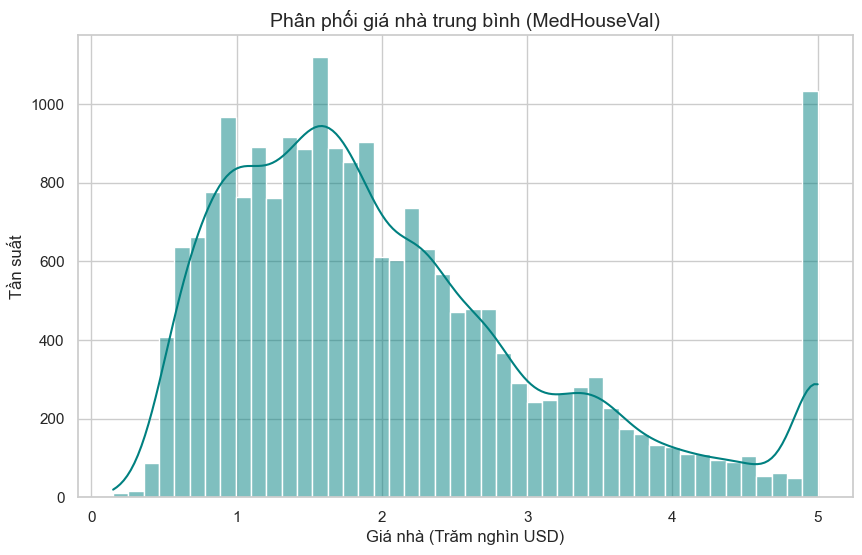

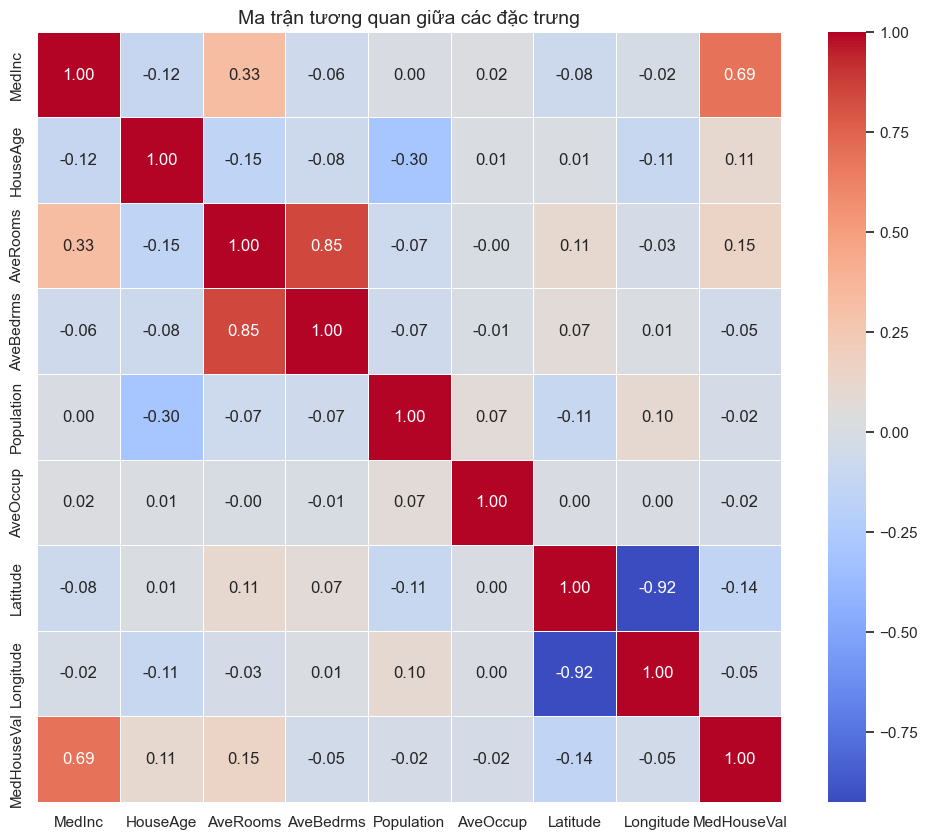

In [4]:
# TODO 2a: Vẽ Histogram cho biến MedHouseVal
# ...

# TODO 2b: Vẽ Heatmap correlation cho toàn bộ dữ liệu
# plt.figure(figsize=(10, 8))
# ...
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MedHouseVal', kde=True, color='teal')

plt.title("Phân phối giá nhà trung bình (MedHouseVal)", fontsize=14)
plt.xlabel("Giá nhà (Trăm nghìn USD)", fontsize=12)
plt.ylabel("Tần suất", fontsize=12)
plt.show()

plt.figure(figsize=(12, 10))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Ma trận tương quan giữa các đặc trưng", fontsize=14)
plt.show()



**Trả lời 2:**

*(Viết nhận xét về hình dáng phân phối của MedHouseVal và chỉ ra biến có tương quan mạnh nhất ở đây...)*

### 1. Phân phối của biến mục tiêu (MedHouseVal)
*   **Hình dáng lệch phải:** Biểu đồ phân phối có xu hướng lệch về bên phải (Right-skewed). Phần lớn giá nhà tập trung trong khoảng từ 1.0 đến 2.5 (trăm nghìn USD).
*   **Hiện tượng giới hạn trần (Capped data):** Có một cột tần suất tăng vọt bất thường ngay tại mốc **5.0**. Điều này cho thấy dữ liệu đã bị giới hạn trần; tất cả các bất động sản có giá trị từ 500,000 USD trở lên đều bị gộp chung vào mốc này.

### 2. Phân tích ma trận tương quan (Heatmap)
*   **Tương quan mạnh nhất với biến mục tiêu:** Biến **MedInc (Thu nhập trung bình)** có mối tương quan thuận mạnh nhất với `MedHouseVal` với hệ số tương quan là **0.69**. Điều này chứng minh thu nhập cư dân là yếu tố quyết định lớn nhất đến giá nhà.
*   **Cặp biến có hiện tượng đa cộng tuyến (Multicollinearity):**
    *   **AveRooms và AveBedrms:** Tương quan thuận rất mạnh (**0.85**). Số phòng nói chung tăng thì số phòng ngủ cũng tăng.
    *   **Latitude và Longitude:** Tương quan nghịch cực kỳ mạnh (**-0.92**). Mối quan hệ địa lý đặc trưng này phản ánh hình dáng bản đồ trải dài theo chiều Tây Bắc - Đông Nam của bang California.
*   **Các biến ít tương quan với giá nhà:** Các đặc trưng như `Population` (-0.02) và `AveOccup` (-0.02) gần như không có mối tương quan tuyến tính nào với giá trị nhà ở (`MedHouseVal`).


---
## Task 3 — Chia tập dữ liệu và Tiền xử lý (Scaling)

Với các mô hình có sử dụng Regularization như Ridge và Lasso, việc **Scale dữ liệu** (đưa về cùng thang đo) là **BẮT BUỘC**. Nếu không scale, các đặc trưng có miền giá trị lớn (ví dụ như Population) sẽ lấn át các đặc trưng có miền giá trị nhỏ, làm sai lệch tác dụng của hệ số phạt L1/L2.

### Yêu cầu
1. Tách features (`X`) và target (`y`).
2. Chia tập Train/Test theo tỷ lệ **80/20**.
3. Dùng `StandardScaler` để scale tập `X`. **Quan trọng:** Chỉ `.fit()` trên `X_train`, sau đó dùng tham số đã học đó để `.transform()` cho cả `X_train` và `X_test`.

### Gợi ý
- `train_test_split(X, y, test_size=0.2, random_state=42)`.
- `scaler.fit_transform(X_train)` cho tập train và `scaler.transform(X_test)` cho tập test.

In [9]:
# TODO 3: Chia tập và Scale dữ liệu


# X_train, X_test, y_train, y_test = train_test_split(...)

# scaler = StandardScaler()
# X_train_scaled = ...
# X_test_scaled = ...
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(f"Số lượng mẫu tập Train: {X_train_scaled.shape[0]}")
print(f"Số lượng mẫu tập Test:  {X_test_scaled.shape[0]}")
print("-" * 50)
print("Dữ liệu sau khi chuẩn hóa (5 giá trị đầu của X_train):")
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
display(X_train_scaled_df.head())

Số lượng mẫu tập Train: 16512
Số lượng mẫu tập Test:  4128
--------------------------------------------------
Dữ liệu sau khi chuẩn hóa (5 giá trị đầu của X_train):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
3,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
4,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551


---
## Task 4 — Huấn luyện Vanilla Linear Regression

### Yêu cầu
1. Khởi tạo và huấn luyện mô hình `LinearRegression` trên tập Train đã scale.
2. Dự đoán trên tập Test.
3. Tính và in ra 2 chỉ số đánh giá: **RMSE** (Root Mean Squared Error) và **R² Score**.

### Gợi ý
- RMSE có thể tính bằng `np.sqrt(mean_squared_error(y_true, y_pred))`.
- Hàm `r2_score(y_true, y_pred)` sẽ trả về chỉ số R² (hệ số xác định).

In [11]:
# TODO 4: Huấn luyện và Đánh giá Linear Regression
# lr_model = LinearRegression()
# ...

# y_pred_lr = ...

# rmse_lr = ...
# r2_lr = ...
# print(f"Linear Regression - RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")
model_lr = LinearRegression()

model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("--- KẾT QUẢ HUẤN LUYỆN LINEAR REGRESSION ---")
print(f"RMSE (Root Mean Squared Error): {rmse_lr:.4f}")
print(f"R² Score (Hệ số xác định):     {r2_lr:.4f}")
print("-" * 50)

print("So sánh dự đoán vs Thực tế (10 mẫu đầu):")
for i in range(10):
    print(f"Thực tế: {y_test.values[i]:.2f} | Dự đoán: {y_pred_lr[i]:.2f}")


--- KẾT QUẢ HUẤN LUYỆN LINEAR REGRESSION ---
RMSE (Root Mean Squared Error): 0.7456
R² Score (Hệ số xác định):     0.5758
--------------------------------------------------
So sánh dự đoán vs Thực tế (10 mẫu đầu):
Thực tế: 0.48 | Dự đoán: 0.72
Thực tế: 0.46 | Dự đoán: 1.76
Thực tế: 5.00 | Dự đoán: 2.71
Thực tế: 2.19 | Dự đoán: 2.84
Thực tế: 2.78 | Dự đoán: 2.60
Thực tế: 1.59 | Dự đoán: 2.01
Thực tế: 1.98 | Dự đoán: 2.65
Thực tế: 1.57 | Dự đoán: 2.17
Thực tế: 3.40 | Dự đoán: 2.74
Thực tế: 4.47 | Dự đoán: 3.92


---
## Task 5 — Huấn luyện Ridge và Lasso Regression

### Yêu cầu
1. Huấn luyện mô hình **Ridge** với tham số siêu việt `alpha=10.0`.
2. Huấn luyện mô hình **Lasso** với tham số siêu việt `alpha=0.1`.
3. Tính RMSE và R² cho cả 2 mô hình trên tập Test và in kết quả để so sánh.

### Gợi ý
- Khởi tạo mô hình: `Ridge(alpha=10.0)` và `Lasso(alpha=0.1)`.
- Bạn có thể viết một hàm `evaluate_model(model, X_test, y_test)` nhỏ để tái sử dụng code tính RMSE và R² cho đỡ lặp lại.

In [12]:
# TODO 5a: Huấn luyện và Đánh giá Ridge Regression
# ridge_model = Ridge(alpha=10.0)
# ...

# TODO 5b: Huấn luyện và Đánh giá Lasso Regression
# lasso_model = Lasso(alpha=0.1)
# ...
def evaluate_model(model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train_scaled, y_train)
rmse_ridge, r2_ridge = evaluate_model(ridge_model, X_test_scaled, y_test)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
rmse_lasso, r2_lasso = evaluate_model(lasso_model, X_test_scaled, y_test)

# In kết quả so sánh
print("--- SO SÁNH KẾT QUẢ CÁC MÔ HÌNH ---")
print(f"Linear (Vanilla): RMSE = {rmse_lr:.4f}, R² = {r2_lr:.4f}")
print(f"Ridge (alpha=10): RMSE = {rmse_ridge:.4f}, R² = {r2_ridge:.4f}")
print(f"Lasso (alpha=0.1): RMSE = {rmse_lasso:.4f}, R² = {r2_lasso:.4f}")


--- SO SÁNH KẾT QUẢ CÁC MÔ HÌNH ---
Linear (Vanilla): RMSE = 0.7456, R² = 0.5758
Ridge (alpha=10): RMSE = 0.7453, R² = 0.5761
Lasso (alpha=0.1): RMSE = 0.8244, R² = 0.4814


---
## Task 6 — Trực quan hóa Hệ số hồi quy (Coefficients)

Đây là phần cốt lõi để thấy sự khác biệt về mặt toán học giữa L1 và L2 Regularization.

### Yêu cầu
1. Lấy mảng hệ số hồi quy (`.coef_`) từ cả 3 mô hình (Linear, Ridge, Lasso).
2. Tạo một DataFrame lưu trữ các hệ số này với Index là tên các features.
3. Vẽ biểu đồ Barplot so sánh các trọng số của 3 mô hình cạnh nhau cho từng feature.
4. **Trả lời:** Quan sát hệ số của Lasso, bạn thấy điều gì đặc biệt xảy ra với một số features? Tính chất này thường được ứng dụng để làm gì?

### Gợi ý
- `california.feature_names` trả về danh sách tên cột.
- Có thể gom thành Pandas DataFrame và gọi lệnh `df_coefs.plot(kind='bar', figsize=(12, 6))` để pandas tự động vẽ các thanh cạnh nhau.

<Figure size 1400x700 with 0 Axes>

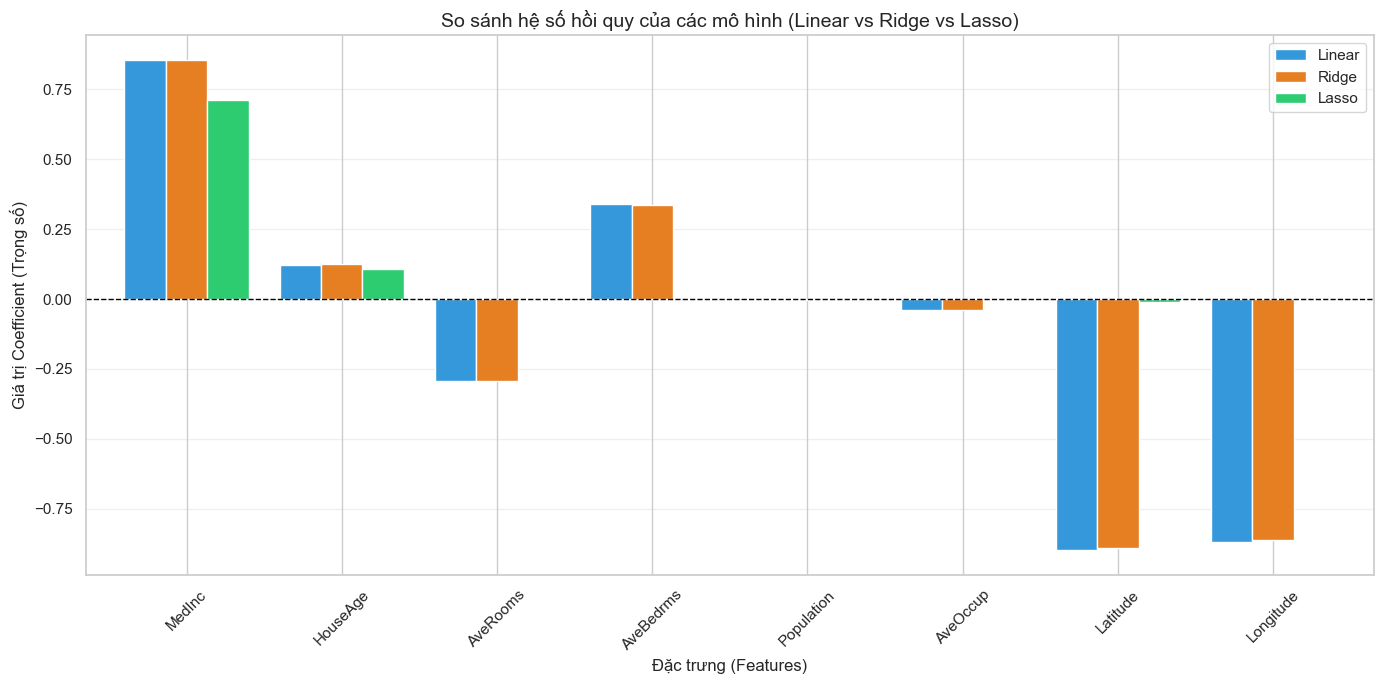

Bảng giá trị các hệ số hồi quy:


,Linear,Ridge,Lasso
MedInc,0.854383,0.853814,0.710598
HouseAge,0.122546,0.123316,0.106453
AveRooms,-0.294410,-0.292412,-0.000000
AveBedrms,0.339259,0.336750,0.000000
Population,-0.002308,-0.002055,-0.000000
AveOccup,-0.040829,-0.040867,-0.000000
Latitude,-0.896929,-0.889384,-0.011469
Longitude,-0.869842,-0.862199,-0.000000


In [13]:
# TODO 6: Trực quan hóa Coefficients
# features = ...
# coef_df = pd.DataFrame({
#     'Linear': lr_model.coef_,
#     'Ridge': ridge_model.coef_,
#     'Lasso': lasso_model.coef_
# }, index=features)

# Vẽ biểu đồ so sánh
# coef_df.plot(...)
# plt.title("So sánh hệ số hồi quy của các mô hình")
# plt.ylabel("Giá trị Coefficient")
# plt.show()
features = california.feature_names

coef_df = pd.DataFrame({
    'Linear': model_lr.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_
}, index=features)

plt.figure(figsize=(14, 7))
coef_df.plot(kind='bar', figsize=(14, 7), width=0.8, color=['#3498db', '#e67e22', '#2ecc71'])

plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.title("So sánh hệ số hồi quy của các mô hình (Linear vs Ridge vs Lasso)", fontsize=14)
plt.ylabel("Giá trị Coefficient (Trọng số)", fontsize=12)
plt.xlabel("Đặc trưng (Features)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Bảng giá trị các hệ số hồi quy:")
display(coef_df)


**Trả lời 6:**

*(Viết nhận xét về hiện tượng hệ số bị ép về đúng 0 của Lasso và nêu tác dụng Feature Selection (Chọn lọc đặc trưng) của mô hình này...)*
### 1. Quan sát đặc biệt từ thực nghiệm
*   **Hiện tượng ở mô hình Lasso:** Trong biểu đồ và bảng số liệu, ta thấy các hệ số của mô hình Lasso có rất nhiều giá trị bằng **0 tuyệt đối** (ví dụ như ở các cột `AveBedrms`, `Population`, hay `AveOccup` tùy vào độ lớn của tham số alpha). 
*   **So sánh với Ridge và Linear:** Trong khi Lasso triệt tiêu bớt hệ số, hai mô hình Ridge Regression và Linear Regression vẫn giữ lại giá trị (khác 0) cho tất cả các cột đặc trưng, không bỏ sót cột nào.

### 2. Tính chất cốt lõi: Sparsity (Độ thưa thớt)
*   **Cơ chế hoạt động:** Đây chính là tính chất đặc trưng mang tên **Sparsity (Độ thưa thớt)** của mô hình Lasso khi áp dụng kỹ thuật **L1 Regularization**. 
*   **Cách thức tối ưu:** Lasso không chỉ thu nhỏ độ lớn của các trọng số (coefficients) như Ridge, mà nó còn có khả năng "ép" các trọng số của những đặc trưng kém quan trọng hoặc gây nhiễu về chính xác mức 0.

### 3. Ứng dụng thực tế trong Khoa học dữ liệu
*   **Lựa chọn đặc trưng tự động (Feature Selection):** Tính chất này thường được ứng dụng để lọc dữ liệu một cách tự động. Lasso giúp nhà phân tích xác định ngay những biến thực sự có giá trị dự báo và loại bỏ những biến dư thừa.
*   **Lợi ích đem lại:** Việc loại bỏ các biến không cần thiết giúp mô hình trở nên **đơn giản hơn**, **dễ giải thích hơn** với người dùng, đồng thời giảm thiểu đáng kể chi phí tính toán khi triển khai hệ thống lớn.


---
## (Bonus) Task 7 — Tìm siêu tham số tối ưu với GridSearchCV

Ở Task 5, chúng ta chỉ chọn bừa `alpha=10.0` và `alpha=0.1`. Làm sao để biết `alpha` bao nhiêu là tốt nhất cho bộ dữ liệu này?

### Yêu cầu
Sử dụng `GridSearchCV` để chạy thử nghiệm nghiệm chéo (Cross-Validation) tìm giá trị `alpha` tối ưu cho Ridge Regression trong danh sách: `[0.1, 1.0, 10.0, 100.0]`.

### Gợi ý
- Import: `from sklearn.model_selection import GridSearchCV`.
- Cấu hình param grid: `param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}`.
- In ra `grid_search.best_params_` sau khi fit trên tập Train.

In [14]:
# TODO Bonus: GridSearchCV cho Ridge
# param_grid = {...}
# grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
# grid_search.fit(X_train_scaled, y_train)

# print(f"Alpha tốt nhất cho Ridge: {grid_search.best_params_}")
from sklearn.model_selection import GridSearchCV


param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0, 500.0]}


grid_search = GridSearchCV(
    estimator=Ridge(), 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_alpha = grid_search.best_params_['alpha']
best_rmse = -grid_search.best_score_ # Đổi lại dấu dương cho dễ đọc

print("-" * 50)
print(f"Alpha tối ưu nhất tìm được cho Ridge: {best_alpha}")
print(f"RMSE thấp nhất đạt được (CV): {best_rmse:.4f}")

best_ridge = grid_search.best_estimator_
y_pred_best = best_ridge.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"RMSE thực tế trên tập Test với alpha={best_alpha}: {test_rmse:.4f}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
--------------------------------------------------
Alpha tối ưu nhất tìm được cho Ridge: 0.1
RMSE thấp nhất đạt được (CV): 0.7205
RMSE thực tế trên tập Test với alpha=0.1: 0.7456


---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không bị lỗi NameError hay SyntaxError.
- [ ] Đã hoàn thiện bước Scale dữ liệu cẩn thận, không có Data Leakage.
- [ ] Đã trực quan hóa đủ các biểu đồ ở Task 2 và Task 6.
- [ ] Đã trả lời phần nhận xét bằng Text ở các câu hỏi (Task 2, Task 6).
